# Run on Kaggle/Colab

In [1]:
# !wget https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/12785291/traintest_hcd.hdf5

In [2]:
!ls /kaggle/input/datasets/bangth/intensity-gen-fm-lib

config.py  models  preprocess.py  requirements.txt  utils


In [3]:
!pip install -r /kaggle/input/datasets/bangth/intensity-gen-fm-lib/requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.8/201.8

In [4]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu124 -q

## Lib integration

In [5]:
import sys
# sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching")
sys.path.append(r"/kaggle/input/datasets/bangth/intensity-gen-fm-lib")
import h5py
from collections import defaultdict, Counter
import numpy as np
# from rich import print

In [6]:
train_path = r"/kaggle/input/datasets/bangth/proteometool-hcd/traintest_hcd.hdf5"

## Open data

## FLow matching training

Preprocessor: Preprocessor(mode=logit)

Device:       cuda

Model params:         4,597,006

Pep embedding params: 3,164,986

Dataset: 6,787,933 samples | 13258 batches/epoch | mode=logit

...

── Validation (log #800) ──
  PCC latent : 0.7496
  SA  latent : 0.9247
  PCC true   : 0.7537
  SA  true   : 0.7952

── Validation (log #900) ──
  PCC latent : 0.7958
  SA  latent : 0.9385
  PCC true   : 0.7834
  SA  true   : 0.8166

── Validation (log #1000) ──
  PCC latent : 0.8378
  SA  latent : 0.9526
  PCC true   : 0.7812
  SA  true   : 0.8053

Training time: 26720.0s

Saved: MLP_2026-05-18 11:45:00.811956_fm_logit_4l_bs512_8e.pth

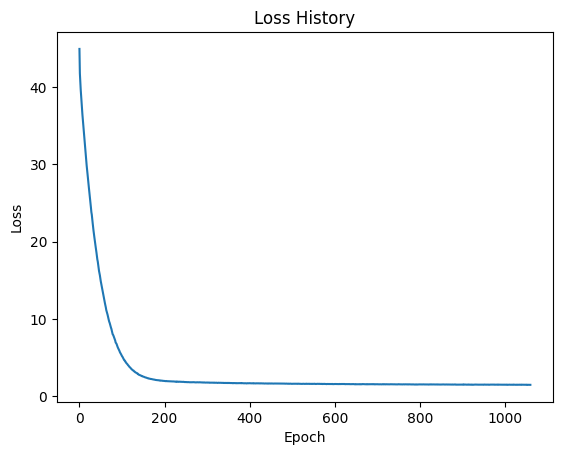

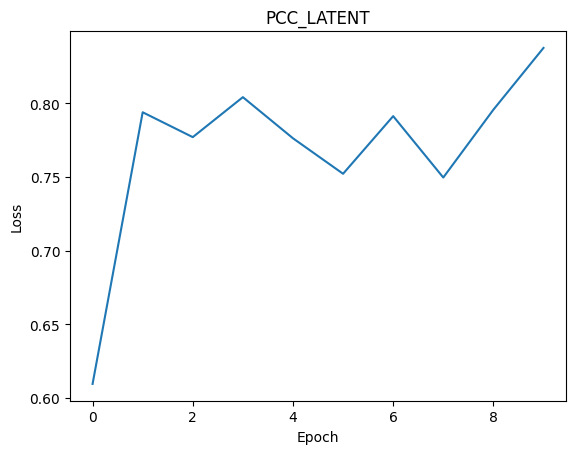

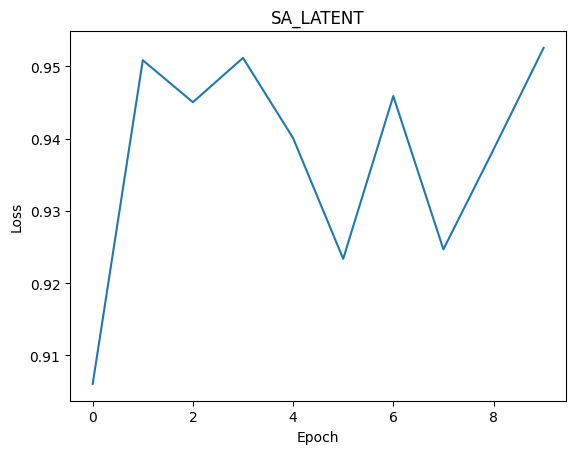

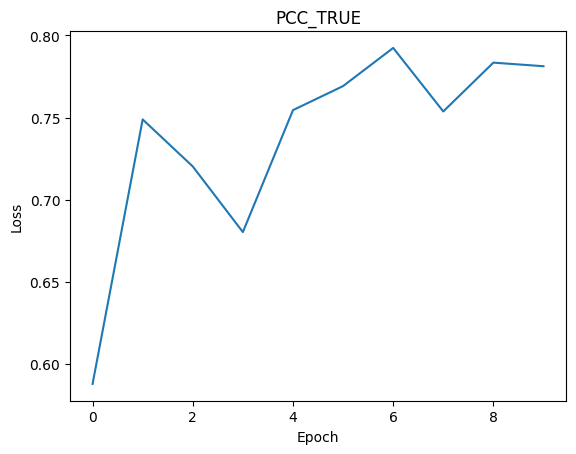

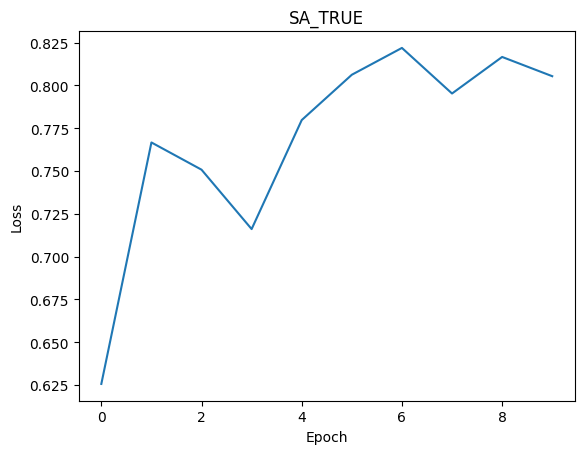

In [7]:
"""
train.py
────────
Training script chính. Mọi hyperparameter và preprocessing mode
đều đặt trong config.py — không cần sửa file này.

Chạy:
    python train.py
"""

import math
from datetime import datetime
from time import time

import h5py
import numpy as np
import torch
from rich import print
from tqdm.auto import tqdm

import config as C
from preprocess import Preprocessor, PreprocessMode
from models import HCDFlowResMLP
from utils.gen_path import get_xt
from utils.metrics import pcc, sa
from utils.utils import (
    create_batch_fragment_mask_from_peptide,
    masked_mse_loss,
    plot_loss_history,
    process_intensity_vector,
)

# ────────────────────────────────────────────────────────────
# Đường dẫn dữ liệu  ← chỉnh ở đây
# ────────────────────────────────────────────────────────────
TRAIN_PATH = r"/kaggle/input/datasets/bangth/proteometool-hcd/traintest_hcd.hdf5"

# ────────────────────────────────────────────────────────────
# Setup
# ────────────────────────────────────────────────────────────
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

preprocessor = Preprocessor(
    mode=C.PREPROCESS_MODE,
    logit_eps=C.LOGIT_EPS,
    sphere_eps=C.SPHERE_EPS,
)
print(f"[bold cyan]Preprocessor:[/bold cyan] {preprocessor}")
print(f"[bold cyan]Device:[/bold cyan]       {device}")


# ────────────────────────────────────────────────────────────
# Helpers
# ────────────────────────────────────────────────────────────
def load_charges(path: str, sample_size: int | None = None) -> np.ndarray:
    with h5py.File(path, "r") as f:
        charges_oh = (
            f["precursor_charge_onehot"][:sample_size]
            if sample_size and sample_size > 0
            else f["precursor_charge_onehot"][:]
        )
    return np.argmax(charges_oh, axis=1) + 1


def build_batch(
    f: h5py.File,
    charges: np.ndarray,
    start: int,
    end: int,
    reshape: bool = False,
) -> dict:
    """Load một batch từ HDF5, trả về dict tensor đã ở trên device."""
    raw_intensities = f["intensities_raw"][start:end]
    raw_seqs        = f["sequence_integer"][start:end]
    batch_charges   = charges[start:end]

    mask_np          = create_batch_fragment_mask_from_peptide(raw_seqs, batch_charges, reshape=reshape)
    intensity_01     = torch.tensor(process_intensity_vector(raw_intensities, reshape), dtype=torch.float64)
    intensity_latent = preprocessor.encode(intensity_01)

    # print(mask_np[0].sum())
    # print(intensity_01[0])
    # print((intensity_01[0] >= 0).sum())
    
    return {
        "intensity_latent": intensity_latent,
        "intensity_01":     intensity_01,
        "pep_seq":          torch.tensor(raw_seqs,      dtype=torch.long),
        "charge":           torch.tensor(batch_charges, dtype=torch.long).unsqueeze(1),
        "mask":             torch.tensor(mask_np,       dtype=torch.bool),
    }


def compute_flow_target(
    noise: torch.Tensor,
    x1:    torch.Tensor,
    t:     torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Tính x_t và velocity target tuỳ theo preprocessing mode.

    Euclidean (raw / logit):
        x_t = (1 - t) * noise + t * x1   [linear interpolation]
        u*  = x1 - noise                  [constant vector field]

    Sphere:
        x_t = SLERP(noise, x1, t)        [geodesic interpolation]
        u*  = Log_{x_t}(x1) / (1-t)      [tangent vector field]
    """
    if preprocessor.mode == PreprocessMode.SPHERE:
        x_t, target = preprocessor.sphere_target_vector(noise, x1, t)
    else:
        x_t    = get_xt(noise, x1, t, sigma=C.SIGMA)
        target = x1 - noise
    return x_t, target


# ────────────────────────────────────────────────────────────
# Model & Optimizer
# ────────────────────────────────────────────────────────────
model = HCDFlowResMLP(
    noise_dim=174,
    pep_dim=256,
    time_dim=64,
    charge_dim=8,
    num_blocks=C.MODEL_LAYERS,
    num_blocks_pep=C.PEP_LAYERS,
    min_charge=1,
    max_charge=6,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=C.LR,
    eps=C.ADAM_EPS,
    weight_decay=C.WEIGHT_DECAY,
)

print(
    f"[bold]Model params:[/bold]         "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)
print(
    f"[bold]Pep embedding params:[/bold] "
    f"{sum(p.numel() for p in model.condition_embedding.parameters() if p.requires_grad):,}"
)


# ────────────────────────────────────────────────────────────
# Tracking
# ────────────────────────────────────────────────────────────
loss_history:   list[float] = []
rolling_buffer: list[float] = []

metrics: dict[str, list[float]] = {
    "pcc_latent": [],
    "sa_latent":  [],
    "pcc_true":   [],
    "sa_true":    [],
}


# ────────────────────────────────────────────────────────────
# Validation helper
# ────────────────────────────────────────────────────────────
def _run_validation(
    model:   torch.nn.Module,
    batch:   dict,
    prep:    Preprocessor,
    metrics: dict,
    n_logs:  int,
) -> None:
    model.eval()
    with torch.no_grad():
        n                = C.VALIDATE_BATCH_SIZE
        intensity_latent = batch["intensity_latent"][:n]
        intensity_01     = batch["intensity_01"][:n]
        pep_seq          = batch["pep_seq"][:n]
        charge           = batch["charge"][:n]
        mask             = batch["mask"][:n]

        noise = torch.randn_like(intensity_latent)
        if prep.mode == PreprocessMode.SPHERE:
            noise = prep.encode(torch.sigmoid(noise))

        gen_latent = model.sample(noise, pep_seq, charge, step=C.ODE_STEPS)
        gen_01     = prep.decode(gen_latent)

        score_pcc_latent = pcc(gen_latent, intensity_latent, mask)
        score_sa_latent  = sa(gen_latent,  intensity_latent, mask)
        score_pcc_true   = pcc(gen_01,     intensity_01,     mask)
        score_sa_true    = sa(gen_01,      intensity_01,     mask)

        metrics["pcc_latent"].append(score_pcc_latent[0])
        metrics["sa_latent"].append(score_sa_latent[0])
        metrics["pcc_true"].append(score_pcc_true[0])
        metrics["sa_true"].append(score_sa_true[0])

        if n_logs % C.PRINT_SCORE_EVERY_N_LOGS == 0:
            print(
                f"\n[cyan]── Validation (log #{n_logs}) ──[/cyan]\n"
                f"  PCC latent : {score_pcc_latent[0]:.4f}\n"
                f"  SA  latent : {score_sa_latent[0]:.4f}\n"
                f"  PCC true   : {score_pcc_true[0]:.4f}\n"
                f"  SA  true   : {score_sa_true[0]:.4f}"
            )
    model.train()


# ────────────────────────────────────────────────────────────
# Training loop
# ────────────────────────────────────────────────────────────
charges     = load_charges(TRAIN_PATH, C.TRAIN_SAMPLE_SIZE)
num_samples = len(charges)
num_batches = math.ceil(num_samples / C.BATCH_SIZE)

print(
    f"\n[bold]Dataset:[/bold] {num_samples:,} samples | "
    f"{num_batches} batches/epoch | "
    f"mode=[yellow]{C.PREPROCESS_MODE}[/yellow]"
)

pbar       = tqdm(range(C.EPOCHS), desc="Epoch")
start_time = time()

with h5py.File(TRAIN_PATH, "r") as f:
    for ep in pbar:
        model.train()
        for b in range(num_batches):
            optimizer.zero_grad()

            start = b * C.BATCH_SIZE
            end   = min((b + 1) * C.BATCH_SIZE, num_samples)

            batch  = build_batch(f, charges, start, end)
            x1     = batch["intensity_latent"]
            noise  = torch.randn_like(x1)
            t      = torch.rand(end - start, 1)

            x_t, target = compute_flow_target(noise, x1, t)
            u_pred       = model(x_t, t, batch["pep_seq"], batch["charge"])
            loss         = masked_mse_loss(u_pred, target, batch["mask"])
            loss.backward()
            optimizer.step()

            rolling_buffer.append(loss.item())

            # ── Log mỗi LOG_EVERY_N_BATCHES ──────────────────
            if len(rolling_buffer) >= C.LOG_EVERY_N_BATCHES:
                mean_loss = sum(rolling_buffer) / len(rolling_buffer)
                rolling_buffer.clear()
                loss_history.append(mean_loss)

                avg_loss = sum(loss_history) / len(loss_history)
                pbar.set_postfix({
                    "rolling": f"{mean_loss:.4f}",
                    "avg":     f"{avg_loss:.4f}",
                })

                n_logs = len(loss_history)
                if n_logs % C.VALIDATE_EVERY_N_LOGS == 0:
                    _run_validation(model, batch, preprocessor, metrics, n_logs)


# ────────────────────────────────────────────────────────────
# Save & Plot
# ────────────────────────────────────────────────────────────
end_time  = time()
print(f"\n[bold green]Training time: {end_time - start_time:.1f}s[/bold green]")

ckpt_name = (
    f"MLP_{datetime.fromtimestamp(end_time)}_"
    f"fm_{C.PREPROCESS_MODE}_{C.MODEL_LAYERS}l_"
    f"bs{C.BATCH_SIZE}_{C.EPOCHS}e.pth"
)
torch.save(model.state_dict(), ckpt_name)
print(f"[bold]Saved:[/bold] {ckpt_name}")

plot_loss_history(loss_history)
for key, vals in metrics.items():
    if vals:
        plot_loss_history(vals, key.upper(), f"MLP_{key.upper()}_{C.PREPROCESS_MODE}")

In [8]:
"""
evaluate.py
───────────
Đánh giá model trên 2 tập:
  1. Train subset  — 1/9 phần đầu của tập train
  2. Holdout       — toàn bộ tập holdout

Mỗi tập báo cáo 3 phương pháp: Single-sample, Best-of-K, Mean-K
với phân nhóm theo peptide length, charge và số replicates.

Chạy:
    python evaluate.py
"""

from __future__ import annotations

import math
from collections import defaultdict
from time import time
from typing import NamedTuple

import h5py
import numpy as np
import torch
from rich import print
from rich.console import Console
from rich.rule import Rule
from rich.table import Table
from tqdm.auto import tqdm

import config as C
from models import HCDFlowResMLP
from preprocess import Preprocessor, PreprocessMode
from utils.metrics import pcc, sa
from utils.utils import (
    create_batch_fragment_mask_from_peptide,
    process_intensity_vector,
)

console = Console()

# ════════════════════════════════════════════════════════════
# CONFIG  ← chỉnh ở đây
# ════════════════════════════════════════════════════════════
TRAIN_PATH   = r"/kaggle/input/datasets/bangth/proteometool-hcd/traintest_hcd.hdf5"
HOLDOUT_PATH = r"/kaggle/input/datasets/bangth/proteometool-hcd/holdout_hcd.hdf5"
MODEL_PATH   = ""           # đường dẫn tới file .pth

K          = 8              # số sample cho best-of-K và mean
EVAL_BATCH = 64             # batch size khi chạy inference
ODE_STEPS  = 6

# Tỷ lệ đầu tập train dùng để đánh giá (1/9 ≈ 11.1%)
TRAIN_EVAL_FRACTION = 1 / 50
# ════════════════════════════════════════════════════════════

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

preprocessor = Preprocessor(
    mode=C.PREPROCESS_MODE,
    logit_eps=C.LOGIT_EPS,
    sphere_eps=C.SPHERE_EPS,
)
print(f"[bold cyan]Device:[/bold cyan]       {device}")
print(f"[bold cyan]Preprocessor:[/bold cyan] {preprocessor}")
print(f"[bold cyan]ODE steps:[/bold cyan]    {ODE_STEPS}")
print(f"[bold cyan]K:[/bold cyan]            {K}")


# ────────────────────────────────────────────────────────────
# Load model
# ────────────────────────────────────────────────────────────
# model = HCDFlowResMLP(
#     noise_dim=174,
#     pep_dim=256,
#     time_dim=64,
#     charge_dim=8,
#     num_blocks=C.MODEL_LAYERS,
#     num_blocks_pep=C.PEP_LAYERS,
#     min_charge=1,
#     max_charge=6,
# )
# if MODEL_PATH:
#     model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
#     print(f"[bold]Loaded:[/bold] {MODEL_PATH}")
# else:
#     print("[yellow]Warning: MODEL_PATH not set, using random weights.[/yellow]")

model.eval()
print(f"[bold]Model params:[/bold] {sum(p.numel() for p in model.parameters()):,}")


# ────────────────────────────────────────────────────────────
# Data loading & grouping
# ────────────────────────────────────────────────────────────
def load_and_group(
    hdf5_path: str,
    max_rows: int | None = None,
    label: str = "",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict, np.ndarray]:
    """
    Đọc HDF5, group các replicate theo (seq, charge), tính ground-truth = mean.

    Trả về:
        seq_arr    (n_unique, seq_len)
        charge_arr (n_unique,)
        len_arr    (n_unique,)          ← peptide length
        gt_arr     (n_unique, 174)      ← mean intensity [0,1]
        groups_raw dict key→[intensities]
        n_replicates (n_unique,)
    """
    print(f"\n[bold]Loading {label}:[/bold] {hdf5_path}")
    with h5py.File(hdf5_path, "r") as f:
        total = f["sequence_integer"].shape[0]
        n_read = min(max_rows, total) if max_rows else total
        seqs        = f["sequence_integer"][:n_read]
        intensities = np.array(f["intensities_raw"][:n_read], dtype=np.float64)
        charge_oh   = f["precursor_charge_onehot"][:n_read]

    charges  = np.argmax(charge_oh, axis=1) + 1
    seq_lens = np.count_nonzero(seqs, axis=1)
    N        = len(seqs)

    print(f"  Rows read: {N:,}")

    groups: dict[tuple, list[np.ndarray]] = defaultdict(list)
    for i in range(N):
        ln = int(seq_lens[i])
        if ln == 0:
            continue
        key = (tuple(int(x) for x in seqs[i, :ln]), int(charges[i]))
        groups[key].append(intensities[i])
        if (i + 1) % 100_000 == 0:
            print(f"  grouped {i+1:,} / {N:,}")

    keys_list    = list(groups.keys())
    n_unique     = len(keys_list)
    n_replicates = np.array([len(v) for v in groups.values()], dtype=np.int64)

    gt_arr     = np.stack(
        [np.mean(v, axis=0).astype(np.float64) for v in groups.values()], axis=0
    )
    seq_arr    = np.zeros((n_unique, seqs.shape[1]), dtype=seqs.dtype)
    charge_arr = np.zeros(n_unique, dtype=np.int64)
    len_arr    = np.zeros(n_unique, dtype=np.int64)

    for idx, (seq_tup, ch) in enumerate(keys_list):
        ln = len(seq_tup)
        seq_arr[idx, :ln] = seq_tup
        charge_arr[idx]   = ch
        len_arr[idx]      = ln

    print(f"  Unique peptides: {n_unique:,}")
    return seq_arr, charge_arr, len_arr, gt_arr, groups, n_replicates


def get_train_max_rows(path: str, fraction: float) -> int:
    with h5py.File(path, "r") as f:
        total = f["sequence_integer"].shape[0]
    return max(1, int(total * fraction))


# ────────────────────────────────────────────────────────────
# Grouping masks
# ────────────────────────────────────────────────────────────
def build_group_masks(
    len_arr:      np.ndarray,
    charge_arr:   np.ndarray,
    n_replicates: np.ndarray,
) -> dict[str, dict[str, np.ndarray]]:
    return {
        "Peptide length": {
            "1–10" : (len_arr >= 1)  & (len_arr <= 10),
            "11–20": (len_arr >= 11) & (len_arr <= 20),
            ">20"  : (len_arr > 20),
        },
        "Charge": {
            "1"  : charge_arr == 1,
            "2–4": (charge_arr >= 2) & (charge_arr <= 4),
            "≥5" : charge_arr >= 5,
        },
        "# replicates": {
            "1–3"  : (n_replicates >= 1)  & (n_replicates <= 3),
            "4–10" : (n_replicates >= 4)  & (n_replicates <= 10),
            "11–20": (n_replicates >= 11) & (n_replicates <= 20),
            ">20"  : n_replicates > 20,
        },
    }


# ────────────────────────────────────────────────────────────
# Scores container
# ────────────────────────────────────────────────────────────
class PerPeptideScores(NamedTuple):
    single_pcc: np.ndarray
    single_sa:  np.ndarray
    bok_pcc:    np.ndarray
    bok_sa:     np.ndarray
    mean_pcc:   np.ndarray
    mean_sa:    np.ndarray


# ────────────────────────────────────────────────────────────
# Inference helpers
# ────────────────────────────────────────────────────────────
def _per_item(metric_fn, gen, gt, mask) -> list[float]:
    result = metric_fn(gen, gt, mask)[1]
    if isinstance(result, torch.Tensor):
        return result.tolist() if result.ndim > 0 else [float(result.item())]
    if isinstance(result, (float, int)):
        return [float(result)]
    return list(result)


def _make_noise(bs: int) -> torch.Tensor:
    noise = torch.randn(bs, 174, dtype=torch.float64, device=device)
    if preprocessor.mode == PreprocessMode.SPHERE:
        noise = preprocessor.encode(torch.sigmoid(noise))
    return noise


def collect_scores(
    seq_arr:    np.ndarray,
    charge_arr: np.ndarray,
    gt_arr:     np.ndarray,
    label:      str = "",
) -> PerPeptideScores:
    """
    Inference một lần qua toàn bộ tập:
      - 1 noise draw  → single-sample
      - K noise draws → best-of-K (argmax PCC) và mean-K
    """
    n_unique    = len(seq_arr)
    num_batches = math.ceil(n_unique / EVAL_BATCH)

    single_pcc_l, single_sa_l = [], []
    bok_pcc_l,    bok_sa_l    = [], []
    mean_pcc_l,   mean_sa_l   = [], []

    for b in tqdm(range(num_batches), desc=f"Inference [{label}]"):
        s, e   = b * EVAL_BATCH, min((b + 1) * EVAL_BATCH, n_unique)
        bs_cur = e - s

        pep_np  = seq_arr[s:e]
        ch_np   = charge_arr[s:e]
        gt_np   = gt_arr[s:e]

        mask_np  = create_batch_fragment_mask_from_peptide(pep_np, ch_np, reshape=False)
        gt_01    = torch.tensor(process_intensity_vector(gt_np, reshape=False), dtype=torch.float64)
        mask_t   = torch.tensor(mask_np,  dtype=torch.bool)
        pep_seq  = torch.tensor(pep_np,   dtype=torch.long)
        charge_t = torch.tensor(ch_np,    dtype=torch.long).unsqueeze(1)

        # ── Single-sample ────────────────────────────────────
        with torch.no_grad():
            gen_latent = model.sample(_make_noise(bs_cur), pep_seq, charge_t, step=ODE_STEPS)
        single_gen = preprocessor.decode(gen_latent)
        single_pcc_l.extend(_per_item(pcc, single_gen, gt_01, mask_t))
        single_sa_l.extend( _per_item(sa,  single_gen, gt_01, mask_t))

        # ── K samples → BoK + Mean ────────────────────────────
        samples:  list[torch.Tensor] = []
        sum_gen = torch.zeros(bs_cur, 174, dtype=torch.float64, device=device)

        for _ in range(K):
            with torch.no_grad():
                gen_latent = model.sample(_make_noise(bs_cur), pep_seq, charge_t, step=ODE_STEPS)
            gen = preprocessor.decode(gen_latent)
            samples.append(gen)
            sum_gen += gen

        # Mean-K
        mean_gen = (sum_gen / K).clamp(0.0, 1.0)
        mean_pcc_l.extend(_per_item(pcc, mean_gen, gt_01, mask_t))
        mean_sa_l.extend( _per_item(sa,  mean_gen, gt_01, mask_t))

        # Best-of-K: argmax PCC per peptide
        pcc_matrix = torch.stack(
            [torch.tensor(_per_item(pcc, s_, gt_01, mask_t)) for s_ in samples], dim=0
        )  # (K, bs_cur)
        best_idx = pcc_matrix.argmax(dim=0)  # (bs_cur,)

        for i in range(bs_cur):
            best  = samples[best_idx[i]][i].unsqueeze(0)
            gt_i  = gt_01[i].unsqueeze(0)
            msk_i = mask_t[i].unsqueeze(0)
            bok_pcc_l.extend(_per_item(pcc, best, gt_i, msk_i))
            bok_sa_l.extend( _per_item(sa,  best, gt_i, msk_i))

    return PerPeptideScores(
        single_pcc = np.array(single_pcc_l),
        single_sa  = np.array(single_sa_l),
        bok_pcc    = np.array(bok_pcc_l),
        bok_sa     = np.array(bok_sa_l),
        mean_pcc   = np.array(mean_pcc_l),
        mean_sa    = np.array(mean_sa_l),
    )


# ────────────────────────────────────────────────────────────
# Report helpers
# ────────────────────────────────────────────────────────────
def _fmt(v: float) -> str:
    return f"{v:.4f}"


def _compute_row(
    scores:   PerPeptideScores,
    n_unique: int,
    mask:     np.ndarray | None = None,
) -> tuple[str, str, str, str, str, str, str]:
    idx = mask if mask is not None else np.ones(n_unique, dtype=bool)
    n   = int(idx.sum())
    if n == 0:
        return ("0", "—", "—", "—", "—", "—", "—")
    return (
        str(n),
        _fmt(scores.single_pcc[idx].mean()),
        _fmt(scores.single_sa[idx].mean()),
        _fmt(scores.bok_pcc[idx].mean()),
        _fmt(scores.bok_sa[idx].mean()),
        _fmt(scores.mean_pcc[idx].mean()),
        _fmt(scores.mean_sa[idx].mean()),
    )


def print_results(
    split_label: str,
    scores:      PerPeptideScores,
    n_unique:    int,
    group_masks: dict[str, dict[str, np.ndarray]],
) -> None:
    console.print(Rule(f"[bold magenta]{split_label}[/bold magenta]"))

    # Overall summary
    ov = Table(
        title=f"Overall  (K={K}, ODE steps={ODE_STEPS}, n={n_unique:,})",
        show_lines=True,
    )
    ov.add_column("Method",     style="bold cyan", justify="left")
    ov.add_column("PCC ↑",      justify="right")
    ov.add_column("SA  ↑",      justify="right")
    ov.add_row("Single-sample",
               _fmt(scores.single_pcc.mean()), _fmt(scores.single_sa.mean()))
    ov.add_row(f"Best-of-{K}",
               _fmt(scores.bok_pcc.mean()),    _fmt(scores.bok_sa.mean()))
    ov.add_row(f"Mean ({K})",
               _fmt(scores.mean_pcc.mean()),   _fmt(scores.mean_sa.mean()))
    console.print(ov)

    # Grouped tables
    for group_name, group_items in group_masks.items():
        t = Table(title=f"Grouped by: {group_name}", show_lines=True)
        t.add_column(group_name,        style="bold",  justify="left")
        t.add_column("N",               style="dim",   justify="right")
        t.add_column("Single PCC",                     justify="right")
        t.add_column("Single SA",                      justify="right")
        t.add_column(f"BoK-{K} PCC",                   justify="right")
        t.add_column(f"BoK-{K} SA",                    justify="right")
        t.add_column(f"Mean-{K} PCC",                  justify="right")
        t.add_column(f"Mean-{K} SA",                   justify="right")

        # Overall row within grouped table
        t.add_row("Overall", *_compute_row(scores, n_unique), style="bold yellow")
        for label, mask in group_items.items():
            t.add_row(label, *_compute_row(scores, n_unique, mask))

        console.print(t)


# ────────────────────────────────────────────────────────────
# Main
# ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    t0 = time()

    # ── 1. Train subset (1/9 đầu) ───────────────────────────
    train_max_rows = get_train_max_rows(TRAIN_PATH, TRAIN_EVAL_FRACTION)
    print(train_max_rows)
    (
        tr_seq, tr_charge, tr_len, tr_gt, _, tr_nrep
    ) = load_and_group(TRAIN_PATH, max_rows=train_max_rows, label="Train subset (1/9)")

    tr_groups = build_group_masks(tr_len, tr_charge, tr_nrep)
    tr_scores = collect_scores(tr_seq, tr_charge, tr_gt, label="Train subset")

    # ── 2. Holdout (toàn bộ) ────────────────────────────────
    (
        ho_seq, ho_charge, ho_len, ho_gt, _, ho_nrep
    ) = load_and_group(HOLDOUT_PATH, max_rows=None, label="Holdout (full)")

    ho_groups = build_group_masks(ho_len, ho_charge, ho_nrep)
    ho_scores = collect_scores(ho_seq, ho_charge, ho_gt, label="Holdout")

    # ── Report ───────────────────────────────────────────────
    print_results(
        split_label = f"Train subset  (first 1/9 of train, {len(tr_seq):,} unique peptides)",
        scores      = tr_scores,
        n_unique    = len(tr_seq),
        group_masks = tr_groups,
    )
    print_results(
        split_label = f"Holdout  (full, {len(ho_seq):,} unique peptides)",
        scores      = ho_scores,
        n_unique    = len(ho_seq),
        group_masks = ho_groups,
    )

    print(f"\n[bold green]Total eval time: {time() - t0:.1f}s[/bold green]")

Device:       cuda

Preprocessor: Preprocessor(mode=logit)

ODE steps:    6

K:            8

Model params: 4,597,006

...

    Overall  (K=8, ODE steps=6,    
             n=63,491)             
┏━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Method        ┃  PCC ↑ ┃  SA  ↑ ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ Single-sample │ 0.8177 │ 0.8401 │
├───────────────┼────────┼────────┤
│ Best-of-8     │ 0.9161 │ 0.9267 │
├───────────────┼────────┼────────┤
│ Mean (8)      │ 0.9226 │ 0.9340 │
└───────────────┴────────┴────────┘

                                    Grouped by: Peptide length                                     
┏━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Peptide length ┃     N ┃ Single PCC ┃ Single SA ┃ BoK-8 PCC ┃ BoK-8 SA ┃ Mean-8 PCC ┃ Mean-8 SA ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Overall        │ 63491 │     0.8177 │    0.8401 │    0.9161 │   0.9267 │     0.9226 │    0.9340 │
├────────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 1–10           │ 15638 │     0.8928 │    0.9117 │    0.9575 │   0.9654 │     0.9536 │    0.9629 │
├────────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 11–20          │ 41669 │     0.8105 │    0.8332 │    0.9141 │   0.9249 │     0.9227 │    0.9340 │
├────────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ >20            │  6184 │     0.6765 │    0.7050 │    0.8255 │   0.8409 │     0.8436 │    0.8610 │
└────────────────┴───────┴────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘

                                     Grouped by: Charge                                     
┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Charge  ┃     N ┃ Single PCC ┃ Single SA ┃ BoK-8 PCC ┃ BoK-8 SA ┃ Mean-8 PCC ┃ Mean-8 SA ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Overall │ 63491 │     0.8177 │    0.8401 │    0.9161 │   0.9267 │     0.9226 │    0.9340 │
├─────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 1       │    53 │     0.3020 │    0.5582 │    0.5819 │   0.7396 │     0.4098 │    0.6673 │
├─────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 2–4     │ 62840 │     0.8200 │    0.8420 │    0.9177 │   0.9280 │     0.9242 │    0.9353 │
├─────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ ≥5      │   598 │     0.6219 │    0.6560 │    0.7840 │   0.8039 │     0.8044 │    0.8267 │
└─────────┴───────┴────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘

                                    Grouped by: # replicates                                     
┏━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ # replicates ┃     N ┃ Single PCC ┃ Single SA ┃ BoK-8 PCC ┃ BoK-8 SA ┃ Mean-8 PCC ┃ Mean-8 SA ┃
┡━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Overall      │ 63491 │     0.8177 │    0.8401 │    0.9161 │   0.9267 │     0.9226 │    0.9340 │
├──────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 1–3          │ 14949 │     0.7714 │    0.7978 │    0.8935 │   0.9062 │     0.8868 │    0.9027 │
├──────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 4–10         │ 11264 │     0.7878 │    0.8129 │    0.9009 │   0.9130 │     0.9077 │    0.9210 │
├──────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ 11–20        │ 34812 │     0.8430 │    0.8632 │    0.9286 │   0.9380 │     0.9405 │    0.9496 │
├──────────────┼───────┼────────────┼───────────┼───────────┼──────────┼────────────┼───────────┤
│ >20          │  2466 │     0.8771 │    0.8936 │    0.9472 │   0.9544 │     0.9561 │    0.9629 │
└──────────────┴───────┴────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘

Total eval time: 2416.6s